In [46]:
# Cell 1: Load the processed dataset and run the SQI core
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    """Find the phase1 project root."""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "preprocessing").is_dir():
            return candidate
        phase1_dir = candidate / "phase1"
        if (phase1_dir / "src" / "preprocessing").is_dir():
            return phase1_dir
    raise FileNotFoundError("Cannot locate the phase1 project root")


def natural_file_key(path: Path) -> list[str | int]:
    """Sort file names in natural numeric order."""
    return [
        int(part) if part.isdigit() else part.lower()
        for part in re.split(r"(\d+)", path.name)
    ]


def estimate_sampling_rate(time_s: np.ndarray) -> float:
    """Estimate sampling rate from positive time intervals."""
    intervals = np.diff(time_s)
    valid = intervals[np.isfinite(intervals) & (intervals > 0)]
    if valid.size == 0:
        raise ValueError("Time axis has no positive finite interval")
    return float(1.0 / np.median(valid))


def find_true_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    """Return start and exclusive end indices of True runs."""
    padded = np.concatenate(([False], mask, [False])).astype(np.int8)
    changes = np.diff(padded)
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    return list(zip(starts, ends))


def sampling_group(fs: float) -> str:
    """Assign a nominal sampling-rate group."""
    if abs(fs - 25.0) <= 1.0:
        return "25 Hz"
    if abs(fs - 50.0) <= 1.0:
        return "50 Hz"
    return "Other"


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_DIR = PROJECT_ROOT / "src"
if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIR))

from dataloader.loader import load_session  # noqa: E402
from preprocessing.sqi import detect_motion_artifacts  # noqa: E402

PROCESSED_COLUMN = "PPG processed"
WINDOW_S = 5.0
THRESHOLD = 4.5
LABEL_NAMES = {0: "Awake", 1: "Drowsy"}
DATASET_DIR = PROJECT_ROOT / "data_processed" / "dhdata"
csv_paths = sorted(DATASET_DIR.glob("*.csv"), key=natural_file_key)
if not csv_paths:
    raise FileNotFoundError(f"No CSV files found in {DATASET_DIR}")

sessions = []
load_rows = []
for csv_path in csv_paths:
    samples = np.nan
    duration_s = np.nan
    fs = np.nan
    try:
        frame, metadata = load_session(csv_path)
        if PROCESSED_COLUMN not in frame.columns:
            raise ValueError(f"Missing column: {PROCESSED_COLUMN}")
        time_s = pd.to_numeric(
            frame["Time (s)"], errors="raise"
        ).to_numpy(dtype=float)
        signal = pd.to_numeric(
            frame[PROCESSED_COLUMN], errors="raise"
        ).to_numpy(dtype=float)
        labels = frame["Label"].to_numpy(copy=True)
        fs = estimate_sampling_rate(time_s)
        mask = detect_motion_artifacts(
            signal, fs, window_s=WINDOW_S, threshold=THRESHOLD
        )
        if mask.shape != signal.shape:
            raise ValueError("SQI mask length does not match the signal")
        if mask.dtype != np.bool_:
            raise TypeError("SQI mask must have boolean dtype")
        samples = len(frame)
        duration_s = time_s[-1] - time_s[0]
        status = "OK"
        sessions.append({
            "session": metadata["file_name"],
            "time": time_s,
            "signal": signal,
            "labels": labels,
            "fs": fs,
            "sampling_group": sampling_group(fs),
            "artifact_mask": mask,
        })
    except (FileNotFoundError, TypeError, ValueError) as exc:
        status = f"Error: {exc}"
    load_rows.append({
        "Session": csv_path.name,
        "Samples": samples,
        "Duration (s)": duration_s,
        "fs (Hz)": fs,
        "SQI status": status,
    })

mpl.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "figure.dpi": 120,
    "font.size": 9,
})
load_table = pd.DataFrame(load_rows)
display(load_table.style.format({
    "Duration (s)": "{:.2f}",
    "fs (Hz)": "{:.3f}",
}).hide(axis="index"))
print(f"SQI completed successfully: {len(sessions)} / {len(csv_paths)}")

Session,Samples,Duration (s),fs (Hz),SQI status
sample_1.csv,117828,2356.54,50.000,OK
sample_4.csv,75416,3028.69,24.992,OK
sample_5.csv,91211,3650.87,25.003,OK
sample_6.csv,79179,3179.80,24.993,OK
sample_7.csv,79768,3203.50,24.994,OK
sample_8.csv,77595,3116.19,24.994,OK
sample_9.csv,119272,4747.33,25.001,OK
sample_10.csv,60386,2425.13,24.998,OK
sample_11.csv,61582,2472.91,24.994,OK
sample_12.csv,89853,3608.36,24.989,OK


SQI completed successfully: 20 / 20


In [47]:
# Cell 2: Summarize artifact burden per session
session_summary_rows = []
for item in sessions:
    mask = item["artifact_mask"]
    fs = item["fs"]
    bounds = find_true_runs(mask)
    window_samples = max(2, int(round(WINDOW_S * fs)))
    full_window_count = len(mask) // window_samples
    window_mask = mask[:full_window_count * window_samples].reshape(
        full_window_count, window_samples
    )
    artifact_window_count = int(window_mask.any(axis=1).sum())
    event_durations_s = np.array([
        (end - start) / fs for start, end in bounds
    ])
    item["artifact_bounds"] = bounds
    session_summary_rows.append({
        "Session": item["session"],
        "Events": len(bounds),
        "Artifact windows": artifact_window_count,
        "Duration (s)": mask.sum() / fs,
        "Duration (%)": 100.0 * mask.mean(),
        "Longest (s)": (
            event_durations_s.max() if event_durations_s.size else 0.0
        ),
    })

session_summary = pd.DataFrame(session_summary_rows)
display(session_summary.style.format({
    "Duration (s)": "{:.2f}",
    "Duration (%)": "{:.3f}",
    "Longest (s)": "{:.2f}",
}).hide(axis="index"))

Session,Events,Artifact windows,Duration (s),Duration (%),Longest (s)
sample_1.csv,2,2,10.00,0.424,5.00
sample_4.csv,0,0,0.00,0.000,0.00
sample_5.csv,1,1,5.00,0.137,5.00
sample_6.csv,0,0,0.00,0.000,0.00
sample_7.csv,0,0,0.00,0.000,0.00
sample_8.csv,0,0,0.00,0.000,0.00
sample_9.csv,0,0,0.00,0.000,0.00
sample_10.csv,0,0,0.00,0.000,0.00
sample_11.csv,0,0,0.00,0.000,0.00
sample_12.csv,0,0,0.00,0.000,0.00


Metric,Value
Total artifact events,3.000
Median artifact duration (%),0.000
IQR artifact duration (%),0.000
Minimum artifact duration (%),0.000
Maximum artifact duration (%),0.424
Sessions without artifact,18.000
Sessions with artifact,2.000


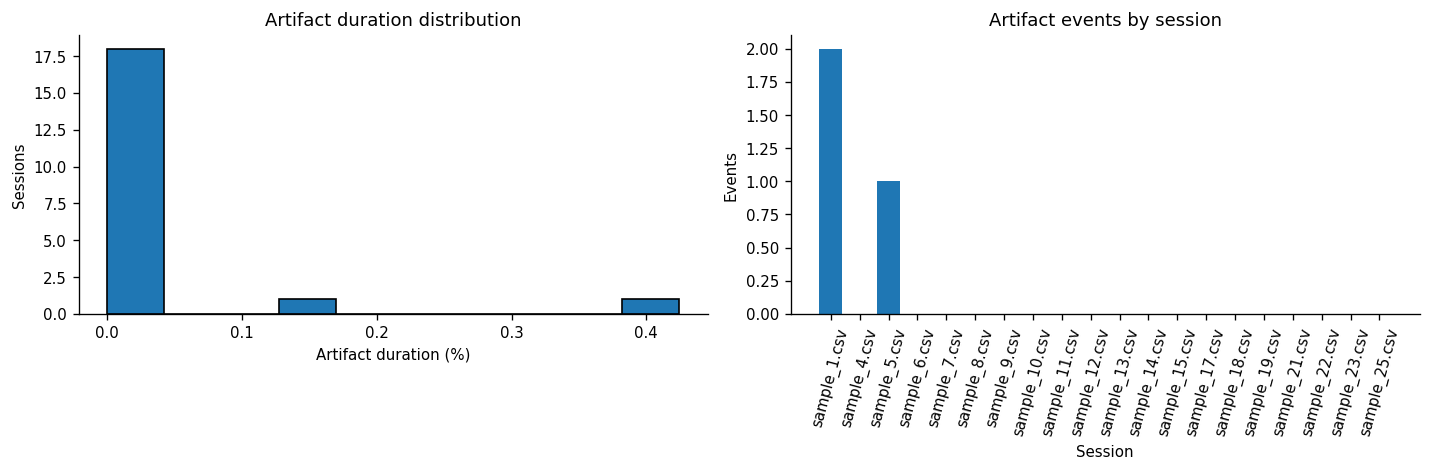

In [48]:
# Cell 3: Summarize the dataset-level artifact distribution
artifact_percentages = session_summary["Duration (%)"]
dataset_artifact_summary = pd.DataFrame({
    "Metric": [
        "Total artifact events",
        "Median artifact duration (%)",
        "IQR artifact duration (%)",
        "Minimum artifact duration (%)",
        "Maximum artifact duration (%)",
        "Sessions without artifact",
        "Sessions with artifact",
    ],
    "Value": [
        session_summary["Events"].sum(),
        artifact_percentages.median(),
        artifact_percentages.quantile(0.75)
        - artifact_percentages.quantile(0.25),
        artifact_percentages.min(),
        artifact_percentages.max(),
        int((session_summary["Events"] == 0).sum()),
        int((session_summary["Events"] > 0).sum()),
    ],
})
display(dataset_artifact_summary.style.format({"Value": "{:.3f}"})
        .hide(axis="index"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(artifact_percentages, bins=10, edgecolor="black")
axes[0].set_title("Artifact duration distribution")
axes[0].set_xlabel("Artifact duration (%)")
axes[0].set_ylabel("Sessions")
axes[1].bar(session_summary["Session"], session_summary["Events"])
axes[1].set_title("Artifact events by session")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Events")
axes[1].tick_params(axis="x", rotation=75)
fig.tight_layout()
plt.show()

In [49]:
# Cell 4: Compare artifact burden between label states
def event_label(labels: np.ndarray) -> str:
    """Return the most frequent event label."""
    modes = pd.Series(labels).mode(dropna=True)
    if modes.empty:
        return "Unknown"
    value = modes.iloc[0]
    return LABEL_NAMES.get(value, str(value))


state_rows = []
state_totals = {
    state: {"duration_s": 0.0, "artifact_s": 0.0}
    for state in LABEL_NAMES.values()
}
for item in sessions:
    row = {"Session": item["session"]}
    event_labels = [
        event_label(item["labels"][start:end])
        for start, end in item["artifact_bounds"]
    ]
    for label_value, state in LABEL_NAMES.items():
        state_mask = item["labels"] == label_value
        state_samples = int(state_mask.sum())
        artifact_samples = int(
            (item["artifact_mask"] & state_mask).sum()
        )
        duration_s = state_samples / item["fs"]
        artifact_s = artifact_samples / item["fs"]
        artifact_percentage = (
            100.0 * artifact_samples / state_samples
            if state_samples
            else np.nan
        )
        row[f"{state} artifact (%)"] = artifact_percentage
        row[f"{state} events"] = event_labels.count(state)
        state_totals[state]["duration_s"] += duration_s
        state_totals[state]["artifact_s"] += artifact_s
    state_rows.append(row)

state_session_summary = pd.DataFrame(state_rows)
display(state_session_summary.style.format({
    "Awake artifact (%)": "{:.3f}",
    "Drowsy artifact (%)": "{:.3f}",
}).hide(axis="index"))
dataset_state_rows = []
for state, totals in state_totals.items():
    dataset_state_rows.append({
        "State": state,
        "Total duration (s)": totals["duration_s"],
        "Artifact duration (s)": totals["artifact_s"],
        "Artifact (%)": (
            100.0 * totals["artifact_s"] / totals["duration_s"]
        ),
    })
dataset_state_summary = pd.DataFrame(dataset_state_rows)
display(dataset_state_summary.style.format({
    "Total duration (s)": "{:.2f}",
    "Artifact duration (s)": "{:.2f}",
    "Artifact (%)": "{:.3f}",
}).hide(axis="index"))
print("State differences are reported descriptively only.")

Session,Awake artifact (%),Awake events,Drowsy artifact (%),Drowsy events
sample_1.csv,0.000,0,1.249,2
sample_4.csv,0.000,0,0.000,0
sample_5.csv,0.211,1,0.000,0
sample_6.csv,0.000,0,0.000,0
sample_7.csv,0.000,0,0.000,0
sample_8.csv,0.000,0,0.000,0
sample_9.csv,0.000,0,0.000,0
sample_10.csv,0.000,0,0.000,0
sample_11.csv,0.000,0,0.000,0
sample_12.csv,0.000,0,0.000,0


State,Total duration (s),Artifact duration (s),Artifact (%)
Awake,40800.25,5.00,0.012
Drowsy,21653.60,10.00,0.046


State differences are reported descriptively only.


Feature condition,Artifact windows,Artifact windows (%)
A exceeds threshold,3,100.00
R exceeds threshold,1,33.33
Both exceed threshold,1,33.33


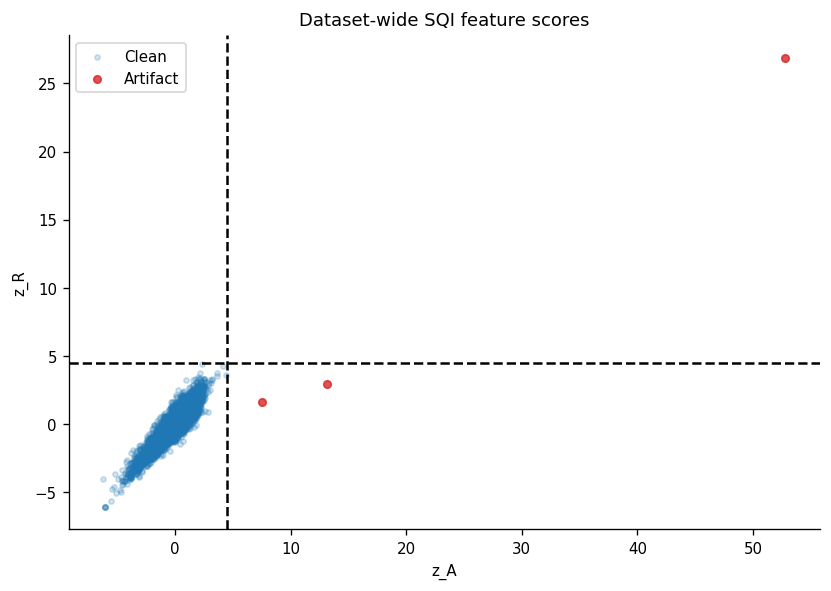

In [50]:
# Cell 5: Reproduce full-window SQI features across the dataset
def calculate_window_features(
    item: dict,
    window_s: float,
    threshold: float,
) -> pd.DataFrame:
    """Calculate the full-window features used by the SQI core."""
    signal = item["signal"]
    window_samples = max(2, int(round(window_s * item["fs"])))
    rows = []
    for start in range(0, len(signal) - window_samples + 1, window_samples):
        end = start + window_samples
        segment = signal[start:end]
        rows.append({
            "Session": item["session"],
            "Start index": start,
            "End index": end,
            "A": np.quantile(segment, 0.95)
            - np.quantile(segment, 0.05),
            "R": np.sqrt(np.mean(np.diff(segment) ** 2)),
        })
    features = pd.DataFrame(rows)
    for feature_name in ("A", "R"):
        values = features[feature_name]
        median = values.median()
        mad = np.median(np.abs(values - median))
        mad = max(float(mad), np.finfo(float).eps)
        features[f"z_{feature_name}"] = (
            0.6745 * (values - median) / mad
        )
    features["A exceeds"] = features["z_A"] > threshold
    features["R exceeds"] = features["z_R"] > threshold
    features["Artifact"] = (
        features["A exceeds"] | features["R exceeds"]
    )
    start_indices = features["Start index"].to_numpy(dtype=int)
    end_indices = features["End index"].to_numpy(dtype=int) - 1
    elapsed_s = item["time"] - item["time"][0]
    features["Start (s)"] = elapsed_s[start_indices]
    features["End (s)"] = elapsed_s[end_indices] + 1.0 / item["fs"]
    features["Label"] = [
        event_label(item["labels"][start:end])
        for start, end in zip(start_indices, end_indices + 1)
    ]
    features["Sampling rate"] = item["sampling_group"]
    return features


feature_tables = []
for item in sessions:
    features = calculate_window_features(item, WINDOW_S, THRESHOLD)
    reconstructed_mask = np.zeros(len(item["signal"]), dtype=bool)
    for row in features.itertuples(index=False):
        if row.Artifact:
            reconstructed_mask[row[1]:row[2]] = True
    if not np.array_equal(reconstructed_mask, item["artifact_mask"]):
        raise AssertionError(
            f"Feature flags do not match core mask: {item['session']}"
        )
    feature_tables.append(features)
window_features = pd.concat(feature_tables, ignore_index=True)
artifact_features = window_features[window_features["Artifact"]]
artifact_window_total = len(artifact_features)
feature_contribution = pd.DataFrame({
    "Feature condition": [
        "A exceeds threshold",
        "R exceeds threshold",
        "Both exceed threshold",
    ],
    "Artifact windows": [
        int(artifact_features["A exceeds"].sum()),
        int(artifact_features["R exceeds"].sum()),
        int((
            artifact_features["A exceeds"]
            & artifact_features["R exceeds"]
        ).sum()),
    ],
})
feature_contribution["Artifact windows (%)"] = (
    100.0 * feature_contribution["Artifact windows"]
    / artifact_window_total
)
display(feature_contribution.style.format({
    "Artifact windows (%)": "{:.2f}",
}).hide(axis="index"))

fig, axis = plt.subplots(figsize=(7, 5))
clean_features = window_features[~window_features["Artifact"]]
axis.scatter(
    clean_features["z_A"],
    clean_features["z_R"],
    color="tab:blue",
    alpha=0.2,
    s=10,
    label="Clean",
)
axis.scatter(
    artifact_features["z_A"],
    artifact_features["z_R"],
    color="tab:red",
    alpha=0.8,
    s=20,
    label="Artifact",
)
axis.axvline(THRESHOLD, color="black", linestyle="--")
axis.axhline(THRESHOLD, color="black", linestyle="--")
axis.set_xlabel("z_A")
axis.set_ylabel("z_R")
axis.set_title("Dataset-wide SQI feature scores")
axis.legend()
fig.tight_layout()
plt.show()

In [51]:
# Cell 6: Select session and window outliers automatically
top_sessions = session_summary.nlargest(3, "Duration (%)").copy()
top_amplitude_windows = artifact_features.nlargest(3, "z_A").copy()
top_roughness_windows = artifact_features.nlargest(3, "z_R").copy()
display(top_sessions[[
    "Session",
    "Events",
    "Artifact windows",
    "Duration (%)",
]].style.format({"Duration (%)": "{:.3f}"}).hide(axis="index"))

window_selection_rows = []
for selection, table in (
    ("Top session", artifact_features[
        artifact_features["Session"].isin(top_sessions["Session"])
    ].sort_values(["Session", "z_A", "z_R"], ascending=False)
     .groupby("Session").head(1)),
    ("Top z_A", top_amplitude_windows),
    ("Top z_R", top_roughness_windows),
):
    selected = table.copy()
    selected["Selection"] = selection
    window_selection_rows.append(selected)
selected_windows = pd.concat(window_selection_rows, ignore_index=True)
selected_windows = selected_windows.drop_duplicates(
    subset=["Session", "Start index"]
).reset_index(drop=True)
selected_columns = [
    "Selection",
    "Session",
    "Start (s)",
    "End (s)",
    "Label",
    "z_A",
    "z_R",
]
display(selected_windows[selected_columns].style.format({
    "Start (s)": "{:.2f}",
    "End (s)": "{:.2f}",
    "z_A": "{:.2f}",
    "z_R": "{:.2f}",
}).hide(axis="index"))

Session,Events,Artifact windows,Duration (%)
sample_1.csv,2,2,0.424
sample_5.csv,1,1,0.137
sample_4.csv,0,0,0.000


Selection,Session,Start (s),End (s),Label,z_A,z_R
Top session,sample_5.csv,2546.85,2551.85,Awake,52.80,26.87
Top session,sample_1.csv,1085.00,1090.00,Drowsy,13.13,2.96
Top z_A,sample_1.csv,2350.00,2355.00,Drowsy,7.54,1.64


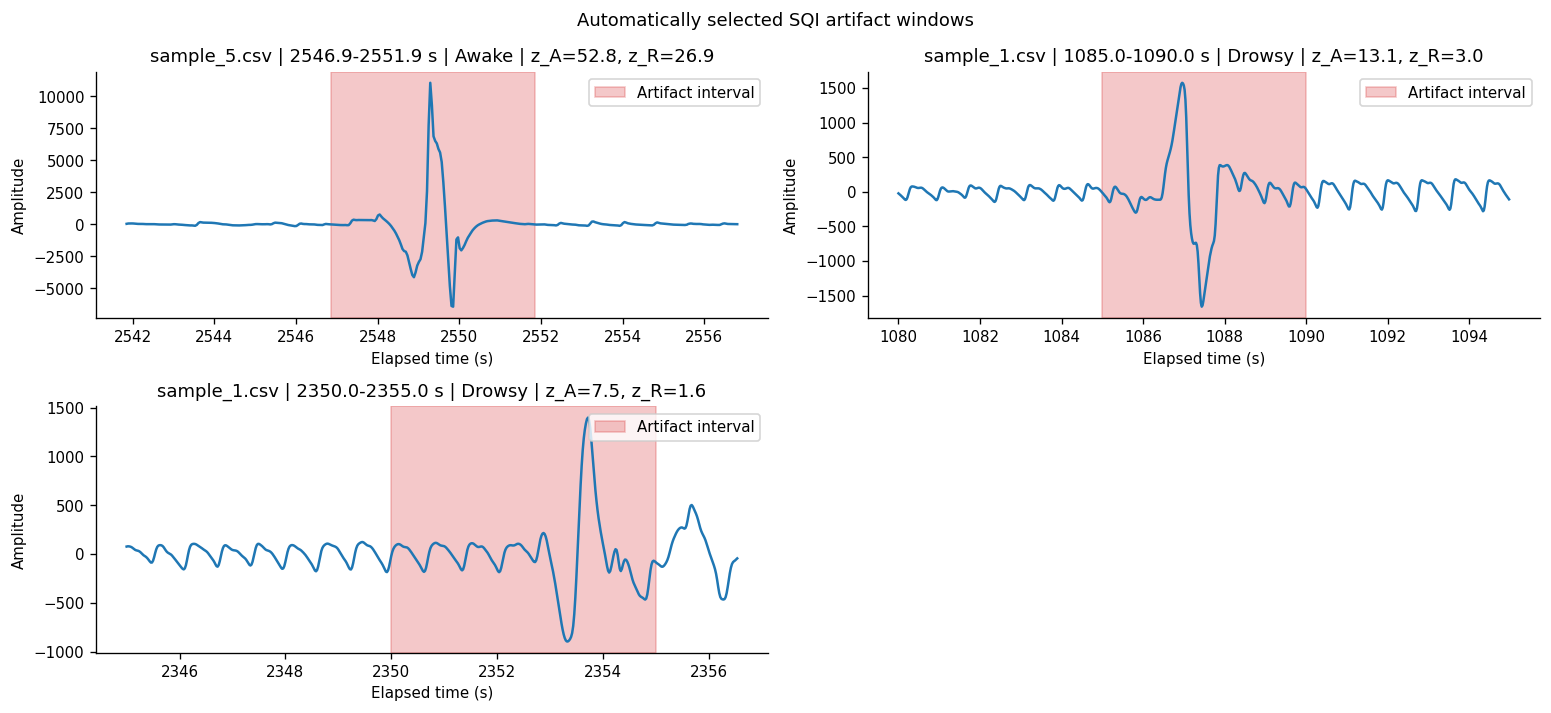

In [52]:
# Cell 7: Inspect automatically selected artifact windows
CONTEXT_S = 5.0
session_lookup = {item["session"]: item for item in sessions}
column_count = 2
row_count = int(np.ceil(len(selected_windows) / column_count))
fig, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(13, 3 * row_count),
    squeeze=False,
)
for axis, (_, row) in zip(axes.flat, selected_windows.iterrows()):
    item = session_lookup[row["Session"]]
    elapsed_s = item["time"] - item["time"][0]
    context_start_s = max(0.0, row["Start (s)"] - CONTEXT_S)
    context_end_s = min(elapsed_s[-1], row["End (s)"] + CONTEXT_S)
    context_mask = (elapsed_s >= context_start_s) & (
        elapsed_s <= context_end_s
    )
    axis.plot(elapsed_s[context_mask], item["signal"][context_mask])
    axis.axvspan(
        row["Start (s)"],
        row["End (s)"],
        color="tab:red",
        alpha=0.25,
        label="Artifact interval",
    )
    axis.set_title(
        f"{row['Session']} | {row['Start (s)']:.1f}-{row['End (s)']:.1f} s | "
        f"{row['Label']} | z_A={row['z_A']:.1f}, z_R={row['z_R']:.1f}"
    )
    axis.set_xlabel("Elapsed time (s)")
    axis.set_ylabel("Amplitude")
    axis.legend(loc="upper right")
for axis in axes.flat[len(selected_windows):]:
    axis.set_visible(False)
fig.suptitle("Automatically selected SQI artifact windows")
fig.tight_layout()
plt.show()

In [53]:
# Cell 8: Compare SQI metrics by sampling-rate group
session_sampling = pd.DataFrame([{
    "Session": item["session"],
    "Sampling rate": item["sampling_group"],
} for item in sessions])
sampling_metrics = session_summary.merge(session_sampling, on="Session")
sampling_rows = []
for group_name in ("25 Hz", "50 Hz"):
    session_group = sampling_metrics[
        sampling_metrics["Sampling rate"] == group_name
    ]
    feature_group = artifact_features[
        artifact_features["Sampling rate"] == group_name
    ]
    sampling_rows.append({
        "Sampling rate": group_name,
        "Sessions": len(session_group),
        "Median artifact duration (%)": session_group[
            "Duration (%)"
        ].median(),
        "Median event count": session_group["Events"].median(),
        "Median artifact z_A": feature_group["z_A"].median(),
        "Median artifact z_R": feature_group["z_R"].median(),
    })
sampling_comparison = pd.DataFrame(sampling_rows)
display(sampling_comparison.style.format({
    "Median artifact duration (%)": "{:.3f}",
    "Median event count": "{:.2f}",
    "Median artifact z_A": "{:.2f}",
    "Median artifact z_R": "{:.2f}",
}).hide(axis="index"))
print("Sampling-rate results are descriptive; no inference is performed.")

Sampling rate,Sessions,Median artifact duration (%),Median event count,Median artifact z_A,Median artifact z_R
25 Hz,19,0.000,0.00,52.80,26.87
50 Hz,1,0.424,2.00,10.34,2.30


Sampling-rate results are descriptive; no inference is performed.


In [54]:
# Cell 9: Evaluate parameter sensitivity across the dataset
WINDOW_OPTIONS_S = [3.0, 5.0, 10.0]
THRESHOLD_OPTIONS = [3.0, 3.5, 4.0]
sensitivity_rows = []
for window_s in WINDOW_OPTIONS_S:
    for threshold in THRESHOLD_OPTIONS:
        total_events = 0
        session_percentages = []
        sessions_flagged = 0
        intersection = 0
        union = 0
        for item in sessions:
            is_reference = (
                window_s == WINDOW_S and threshold == THRESHOLD
            )
            test_mask = (
                item["artifact_mask"]
                if is_reference
                else detect_motion_artifacts(
                    item["signal"],
                    item["fs"],
                    window_s=window_s,
                    threshold=threshold,
                )
            )
            main_mask = item["artifact_mask"]
            event_count = len(find_true_runs(test_mask))
            total_events += event_count
            session_percentages.append(100.0 * test_mask.mean())
            sessions_flagged += int(test_mask.any())
            intersection += int((test_mask & main_mask).sum())
            union += int((test_mask | main_mask).sum())
        sensitivity_rows.append({
            "Window (s)": window_s,
            "Threshold": threshold,
            "Events": total_events,
            "Median artifact (%)": np.median(session_percentages),
            "Sessions flagged": sessions_flagged,
            "Mask overlap": intersection / union if union else 1.0,
        })

parameter_sensitivity = pd.DataFrame(sensitivity_rows)
display(parameter_sensitivity.style.format({
    "Window (s)": "{:.0f}",
    "Threshold": "{:.1f}",
    "Median artifact (%)": "{:.3f}",
    "Mask overlap": "{:.3f}",
}).hide(axis="index"))

Window (s),Threshold,Events,Median artifact (%),Sessions flagged,Mask overlap
3,3.0,33,0.169,13,0.108
3,3.5,16,0.047,10,0.230
3,4.0,8,0.000,6,0.415
5,3.0,27,0.126,11,0.143
5,3.5,8,0.000,7,0.455
5,4.0,6,0.000,5,0.625
10,3.0,17,0.114,10,0.075
10,3.5,5,0.000,5,0.188
10,4.0,3,0.000,3,0.300


In [55]:
# Cell 10: Estimate SQI impact on candidate analysis windows
ANALYSIS_WINDOWS_S = [60, 120, 180, 240, 300]
segmentation_rows = []
for duration_s in ANALYSIS_WINDOWS_S:
    candidate_count = 0
    rejected_count = 0
    for item in sessions:
        window_samples = int(round(duration_s * item["fs"]))
        starts = range(
            0,
            len(item["artifact_mask"]) - window_samples + 1,
            window_samples,
        )
        for start in starts:
            end = start + window_samples
            candidate_count += 1
            rejected_count += int(item["artifact_mask"][start:end].any())
    retained_count = candidate_count - rejected_count
    segmentation_rows.append({
        "Window length (s)": duration_s,
        "Candidate": candidate_count,
        "Rejected by SQI": rejected_count,
        "Retained": retained_count,
        "Retention (%)": 100.0 * retained_count / candidate_count,
    })
segmentation_impact = pd.DataFrame(segmentation_rows)
display(segmentation_impact.style.format({
    "Retention (%)": "{:.2f}",
}).hide(axis="index"))

Window length (s),Candidate,Rejected by SQI,Retained,Retention (%)
60,1030,2,1028,99.81
120,510,2,508,99.61
180,337,2,335,99.41
240,250,2,248,99.20
300,199,2,197,98.99


In [56]:
# Cell 11: Build the final dataset-wide SQI summary
state_burden_text = ", ".join(
    f"{row['State']}: {row['Artifact (%)']:.3f}%"
    for _, row in dataset_state_summary.iterrows()
)
feature_text = ", ".join(
    f"{row['Feature condition']}: {row['Artifact windows (%)']:.2f}%"
    for _, row in feature_contribution.iterrows()
)
outlier_text = ", ".join(top_sessions["Session"].tolist())
non_reference = parameter_sensitivity[
    ~((parameter_sensitivity["Window (s)"] == WINDOW_S)
      & (parameter_sensitivity["Threshold"] == THRESHOLD))
]
overlap_range = (
    f"{non_reference['Mask overlap'].min():.3f}-"
    f"{non_reference['Mask overlap'].max():.3f}"
)
retention_range = (
    f"{segmentation_impact['Retention (%)'].min():.2f}-"
    f"{segmentation_impact['Retention (%)'].max():.2f}%"
)
final_sqi_summary = pd.DataFrame({
    "Topic": [
        "Artifact prevalence",
        "Awake/Drowsy burden",
        "Feature contribution",
        "Top session outliers",
        "Parameter mask overlap",
        "Segmentation retention",
    ],
    "Result": [
        (
            f"{int(session_summary['Events'].sum())} events; median "
            f"{artifact_percentages.median():.3f}% per session"
        ),
        state_burden_text,
        feature_text,
        outlier_text,
        overlap_range,
        retention_range,
    ],
})
display(final_sqi_summary.style.hide(axis="index"))
display(segmentation_impact.style.format({
    "Retention (%)": "{:.2f}",
}).hide(axis="index"))
print(
    "Review the targeted plots with the ready-to-freeze criteria; "
    "no automatic freeze decision is applied."
)

Topic,Result
Artifact prevalence,3 events; median 0.000% per session
Awake/Drowsy burden,"Awake: 0.012%, Drowsy: 0.046%"
Feature contribution,"A exceeds threshold: 100.00%, R exceeds threshold: 33.33%, Both exceed threshold: 33.33%"
Top session outliers,"sample_1.csv, sample_5.csv, sample_4.csv"
Parameter mask overlap,0.075-0.625
Segmentation retention,98.99-99.81%


Window length (s),Candidate,Rejected by SQI,Retained,Retention (%)
60,1030,2,1028,99.81
120,510,2,508,99.61
180,337,2,335,99.41
240,250,2,248,99.20
300,199,2,197,98.99


Review the targeted plots with the ready-to-freeze criteria; no automatic freeze decision is applied.


## Tổng hợp kết quả thực nghiệm SQI với threshold 4,5

### 1. Dữ liệu và cấu hình

- Notebook đọc và xử lý thành công **20/20 processed session** trong `data_processed/dhdata`.
- Mỗi session sử dụng `Time (s)`, `PPG processed` và `Label`.
- Cấu hình SQI chính trong lần chạy này là `window_s = 5,0` và `threshold = 4,5`.
- Tất cả output mask có cùng chiều dài với signal tương ứng và có kiểu boolean.
- Không có session phát sinh runtime error.
- Dataset gồm **1 session 50 Hz** (`sample_1.csv`) và **19 session xấp xỉ 25 Hz**.
- Số mẫu mỗi session nằm trong khoảng **60.386--119.272 mẫu**; thời lượng nằm trong khoảng **2.356,54--4.747,33 giây**.
- Tổng thời lượng theo label là **62.453,85 giây**, gồm Awake **40.800,25 giây** và Drowsy **21.653,60 giây**.

### 2. Artifact burden theo session

Có **2 session** chứa artifact và **18 session** không có artifact.

| Session | Events | Artifact windows | Duration (s) | Duration (%) | Longest (s) |
| --- | ---: | ---: | ---: | ---: | ---: |
| `sample_1.csv` | 2 | 2 | 10,00 | 0,424 | 5,00 |
| `sample_5.csv` | 1 | 1 | 5,00 | 0,137 | 5,00 |

Các session còn lại có `Events = 0`, `Artifact windows = 0` và `Duration (%) = 0,000`.

### 3. Phân bố artifact trên toàn dataset

- Tổng số artifact event: **3**.
- Tổng số artifact window: **3**.
- Tổng artifact duration: **15,00 giây**.
- Median artifact duration theo session: **0,000%**.
- IQR artifact duration theo session: **0,000%**.
- Minimum artifact duration theo session: **0,000%**.
- Maximum artifact duration theo session: **0,424%**.
- Histogram artifact duration (%) và biểu đồ số event theo session đã được tạo trong notebook.

### 4. Artifact burden theo Awake và Drowsy

| State | Total duration (s) | Artifact duration (s) | Artifact (%) | Events |
| --- | ---: | ---: | ---: | ---: |
| Awake | 40.800,25 | 5,00 | 0,012 | 1 |
| Drowsy | 21.653,60 | 10,00 | 0,046 | 2 |

Awake artifact nằm trong `sample_5.csv`. Hai Drowsy artifact event nằm trong `sample_1.csv`. Các số liệu được báo cáo theo label và không được diễn giải thành hiệu ứng sinh lý.

### 5. Feature-level diagnostic

Feature `A`, `R`, `z_A`, `z_R` và artifact flag được tính lại trên toàn bộ full 5-second window. Mask tái tạo từ feature flag trùng với mask trả về bởi core cho cả 20 session.

| Feature condition | Artifact windows | Artifact windows (%) |
| --- | ---: | ---: |
| `z_A > 4,5` | 3 | 100,00 |
| `z_R > 4,5` | 1 | 33,33 |
| Cả `z_A` và `z_R` đều vượt threshold | 1 | 33,33 |

Các tỷ lệ của `A` và `R` được tính inclusive; window vượt cả hai threshold xuất hiện trong cả ba hàng tương ứng. Scatter `z_A` theo `z_R` đã được tạo với artifact window được highlight và threshold line tại 4,5.

### 6. Session và artifact window được chọn tự động

Bảng top 3 session theo artifact duration (%) gồm:

| Session | Events | Artifact windows | Duration (%) |
| --- | ---: | ---: | ---: |
| `sample_1.csv` | 2 | 2 | 0,424 |
| `sample_5.csv` | 1 | 1 | 0,137 |
| `sample_4.csv` | 0 | 0 | 0,000 |

`sample_4.csv` xuất hiện ở vị trí thứ ba do chỉ có hai session có artifact và các session còn lại cùng có duration bằng 0. Sau khi kết hợp top session, top `z_A`, top `z_R` và loại window trùng nhau, danh sách visual inspection gồm:

| Selection | Session | Interval (s) | Label | z_A | z_R |
| --- | --- | --- | --- | ---: | ---: |
| Top session | `sample_5.csv` | 2.546,85--2.551,85 | Awake | 52,80 | 26,87 |
| Top session | `sample_1.csv` | 1.085,00--1.090,00 | Drowsy | 13,13 | 2,96 |
| Top z_A | `sample_1.csv` | 2.350,00--2.355,00 | Drowsy | 7,54 | 1,64 |

Notebook đã vẽ PPG processed của ba window trên cùng 5 giây context trước và sau artifact, highlight artifact interval và hiển thị session, interval, label, `z_A`, `z_R`.

### 7. So sánh theo sampling rate

| Sampling rate | Sessions | Median artifact duration (%) | Median events | Median artifact z_A | Median artifact z_R |
| --- | ---: | ---: | ---: | ---: | ---: |
| 25 Hz | 19 | 0,000 | 0,00 | 52,80 | 26,87 |
| 50 Hz | 1 | 0,424 | 2,00 | 10,34 | 2,30 |

Các median `z_A` và `z_R` trong bảng được tính trên artifact window. Nhóm 25 Hz có một artifact window thuộc `sample_5.csv`; nhóm 50 Hz có hai artifact window thuộc `sample_1.csv`. Nhóm 50 Hz chỉ gồm một session nên không có statistical inference.

### 8. Parameter sensitivity

Các cấu hình sensitivity sử dụng `window_s = 3, 5, 10` và `threshold = 3,0, 3,5, 4,0`. Mask overlap là Jaccard so với mask chính `5 s / 4,5`; cấu hình chính 4,5 không nằm trong chín hàng sensitivity.

| Window (s) | Threshold | Events | Median artifact (%) | Sessions flagged | Mask overlap |
| ---: | ---: | ---: | ---: | ---: | ---: |
| 3 | 3,0 | 33 | 0,169 | 13 | 0,108 |
| 3 | 3,5 | 16 | 0,047 | 10 | 0,230 |
| 3 | 4,0 | 8 | 0,000 | 6 | 0,415 |
| 5 | 3,0 | 27 | 0,126 | 11 | 0,143 |
| 5 | 3,5 | 8 | 0,000 | 7 | 0,455 |
| 5 | 4,0 | 6 | 0,000 | 5 | 0,625 |
| 10 | 3,0 | 17 | 0,114 | 10 | 0,075 |
| 10 | 3,5 | 5 | 0,000 | 5 | 0,188 |
| 10 | 4,0 | 3 | 0,000 | 3 | 0,300 |

Trong chín cấu hình sensitivity, tổng event nằm trong khoảng **3--33**, số session được flag nằm trong khoảng **3--13**, và Jaccard overlap so với mask `5 s / 4,5` nằm trong khoảng **0,075--0,625**.

### 9. Ảnh hưởng dự kiến đến segmentation

Candidate window được tạo không chồng lấp và chỉ sử dụng window đầy đủ. Một candidate bị reject khi chứa ít nhất một sample có artifact mask.

| Window length (s) | Candidate | Rejected by SQI | Retained | Retention (%) |
| ---: | ---: | ---: | ---: | ---: |
| 60 | 1.030 | 2 | 1.028 | 99,81 |
| 120 | 510 | 2 | 508 | 99,61 |
| 180 | 337 | 2 | 335 | 99,41 |
| 240 | 250 | 2 | 248 | 99,20 |
| 300 | 199 | 2 | 197 | 98,99 |

Retention nằm trong khoảng **98,99--99,81%** đối với năm độ dài analysis window. SQI chỉ tạo mask để flag hoặc reject; tín hiệu không được sửa hay nội suy.

### 10. Phạm vi tổng hợp

Các số liệu trên mô tả output của lần chạy với threshold 4,5 và các cấu hình sensitivity. Notebook không tự động đưa ra quyết định freeze hoặc đánh giá chất lượng SQI.

# CONCLUSION


# SQI — Kết luận cuối cùng

Cấu hình SQI được freeze:

```text
Input       = PPG processed
Window      = 5 s
Features    = robust amplitude + RMS first difference
Baseline    = session-relative median/MAD
Threshold   = 4.5
Decision    = z_A > 4.5 OR z_R > 4.5
Output      = sample-level boolean artifact mask
````

## Bằng chứng chính

* Xử lý thành công **20/20 session**.
* Chỉ phát hiện **3 artifact window / 3 events** trong **2/20 session**.
* Tổng artifact duration: **15 s / 62,453.85 s**.
* Các artifact được phát hiện tương ứng với waveform abnormality rõ ràng khi visual inspection.
* Không ghi nhận dấu hiệu state bias đáng kể:

  * Awake artifact: **0.012%**
  * Drowsy artifact: **0.046%**
* Segmentation dự kiến vẫn giữ **98.99–99.81%** candidate windows.
* SQI chỉ flag/reject artifact, không sửa hoặc nội suy tín hiệu.

## Kết luận

**SQI với window 5 s và threshold 4.5 được xem là ready to freeze.**

Thiết kế này ưu tiên specificity cao và chỉ loại các artifact rõ ràng, phù hợp với mục tiêu bảo toàn cấu trúc động lực học của PPG cho các phân tích nonlinear downstream.

```



In [59]:
# Cell 12: Save the sample-level SQI mask to processed CSV files
save_rows = []
for item in sessions:
    csv_path = DATASET_DIR / item["session"]
    frame = pd.read_csv(csv_path)
    mask = item["artifact_mask"]

    if len(frame) != len(mask):
        raise ValueError(
            f"SQI length mismatch for {csv_path.name}: "
            f"{len(mask)} mask values for {len(frame)} rows"
        )

    frame["SQI"] = mask
    temporary_path = csv_path.with_suffix(".tmp")
    frame.to_csv(temporary_path, index=False)
    temporary_path.replace(csv_path)

    artifact_count = int(mask.sum())
    save_rows.append({
        "Session": csv_path.name,
        "Rows": len(frame),
        "Artifact samples": artifact_count,
        "Artifact (%)": 100.0 * artifact_count / len(frame),
        "Status": "Saved",
    })

sqi_save_summary = pd.DataFrame(save_rows)
display(sqi_save_summary.style.format({
    "Artifact (%)": "{:.3f}",
}).hide(axis="index"))
print(
    f"Saved boolean SQI masks to {len(save_rows)} CSV files. "
    "SQI=True indicates an artifact sample."
)

Session,Rows,Artifact samples,Artifact (%),Status
sample_1.csv,117828,500,0.424,Saved
sample_4.csv,75416,0,0.000,Saved
sample_5.csv,91211,125,0.137,Saved
sample_6.csv,79179,0,0.000,Saved
sample_7.csv,79768,0,0.000,Saved
sample_8.csv,77595,0,0.000,Saved
sample_9.csv,119272,0,0.000,Saved
sample_10.csv,60386,0,0.000,Saved
sample_11.csv,61582,0,0.000,Saved
sample_12.csv,89853,0,0.000,Saved


Saved boolean SQI masks to 20 CSV files. SQI=True indicates an artifact sample.
